In [1]:
!pip install torchview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchview import draw_graph
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import inv_boxcox
from scipy.stats import boxcox
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cpu'


In [4]:
dataset = pd.read_csv("/home/zorinep/ml/notebooks/myself-ml-challenge/data/datasets/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [5]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

In [10]:
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
clean_dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


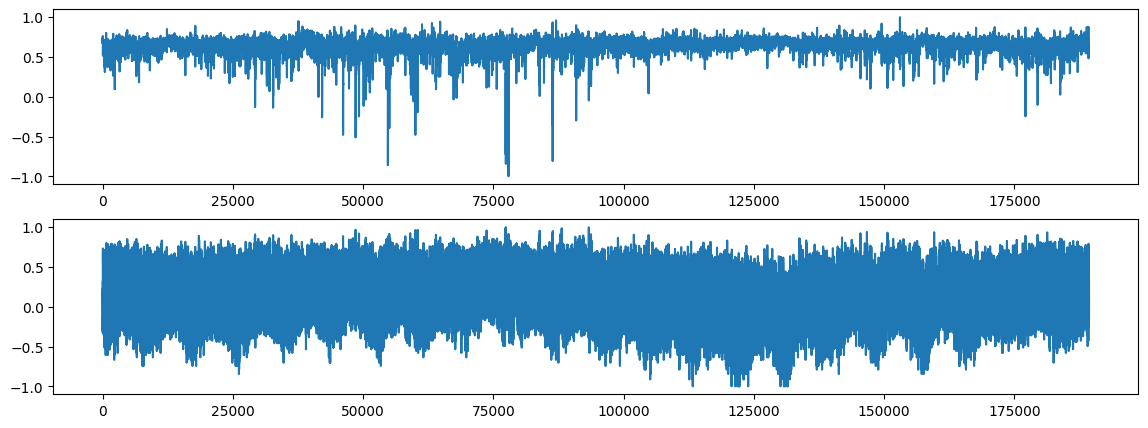

In [11]:
dataset_to_preprocess = clean_dataset.copy()

lmbda = 0
ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

dataset_to_preprocess["AE"] = ae_log_data
# 90% train, 10% test
train_size = int(len(dataset_to_preprocess) * 0.9)

train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]

X_train, y_train = train.drop(columns=["datetime", "Dst", "AE"]), train[["Dst", "AE"]]
X_test, y_test = test.drop(columns=["datetime", "Dst", "AE"]), test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

In [9]:
import joblib

joblib.dump(X_scaler, 'X_scaler.joblib') 
joblib.dump(y_scaler, 'y_scaler.joblib') 

['y_scaler.joblib']

In [9]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [14]:
X_window_size = 24*7  # 2 недели
y_window_size = 6
batch_size = 32
stride = y_window_size

train_dataset = GeomagneticDataset(
    X=X_train_scaled,
    y=y_train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
test_dataset = GeomagneticDataset(
    X=X_test_scaled,
    y=y_test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
class GeomagneticModelV2(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        attention_num_heads: int,
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_input_size,
            num_heads=attention_num_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.attention_norm = nn.LayerNorm(lstm_input_size)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(lstm_dropout)

        heads_hidden_size = lstm_hidden_size * 2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        attn_out, attn_weights = self.attention(x, x, x)
        x = self.attention_norm(x + attn_out)
        lstm_out, _ = self.rnn_feature_extractor(x)
        features = lstm_out[:, -1, :]
        features = self.dropout(features)

        dst = self.dst_head(features)
        ae = self.ae_head(features)

        return dst, ae, attn_weights

Кол-во весов: 4242068


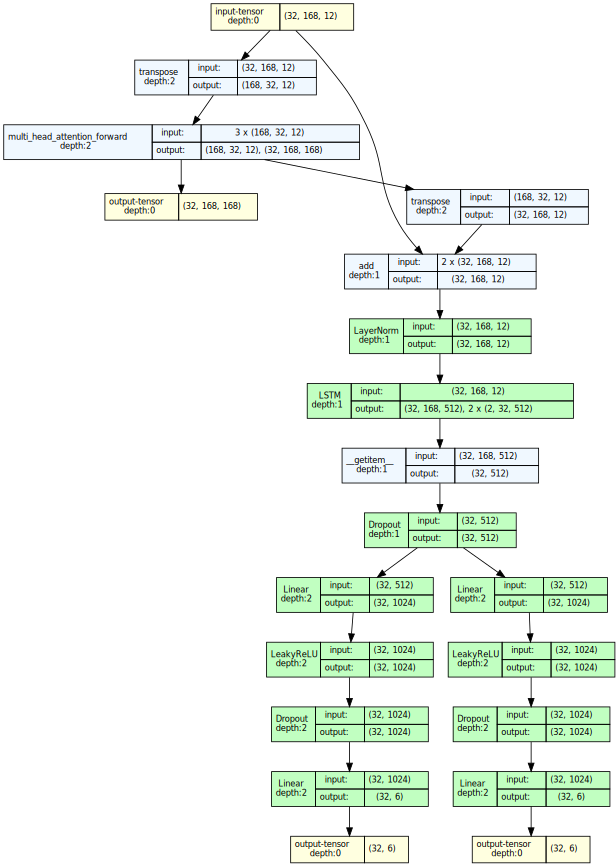

In [ ]:
initial_lr = 1e-3
EPOCHS = 150

lr_scheduler_factor = 0.5      # Умножаем lr на 0.5 при плато
lr_scheduler_patience = 10     # Ждем 10 эпох без улучшения
lr_scheduler_threshold = 1e-4  # Минимальное улучшение для сброса счетчика
lr_scheduler_cooldown = 5      # После снижения lr ждем 5 эпох
lr_scheduler_min_lr = 1e-6     # Минимальный lr

baseline_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)

print(f"Кол-во весов: {sum([i.numel() for i in baseline_model.parameters()])}")
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=initial_lr, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_scheduler_factor,
    patience=lr_scheduler_patience,
    threshold=lr_scheduler_threshold,
    cooldown=lr_scheduler_cooldown,
    min_lr=lr_scheduler_min_lr,
)
graph = draw_graph(baseline_model, input_size=[batch_size, X_window_size, 12])
graph.visual_graph

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
patience_counter = 0
patience_delta = 1e-4
patience = 50

best_val_loss = float('inf')
best_epoch = 0

history_train = {
    "dst_loss": [],
    "ae_loss": [],
    "summary_loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}
history_val = {
    "loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}

baseline_model.to(device)

for e in range(EPOCHS):
    # ========== TRAIN ==========
    baseline_model.train()
    train_progress = tqdm(train_loader)
    running_history = {
        "dst_loss": [],
        "ae_loss": [],
        "summary_loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }

    for x, y in train_progress:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        dst_y, ae_y = y[:, :, 0], y[:, :, 1]
        dst_y_pred, ae_y_pred, _ = baseline_model(x)

        dst_loss = loss_fn(dst_y_pred, dst_y)
        ae_loss = loss_fn(ae_y_pred, ae_y)
        loss = dst_loss + ae_loss

        loss.backward()
        optimizer.step()

        # Метрики для логирования
        with torch.no_grad():
            pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                 ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
            label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                  ae_y.detach().cpu().numpy().flatten()], axis=1)
            pred_data = y_scaler.inverse_transform(pred_data)
            pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
            label_data = y_scaler.inverse_transform(label_data)
            label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

            dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
            ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
            dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
            ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
            dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
            ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

            running_history["dst"]["RMSE"].append(dst_rmse)
            running_history["ae"]["RMSE"].append(ae_rmse)
            running_history["dst"]["MAPE"].append(dst_mape)
            running_history["ae"]["MAPE"].append(ae_mape)
            running_history["dst"]["MAE"].append(dst_mae)
            running_history["ae"]["MAE"].append(ae_mae)
            running_history["dst_loss"].append(dst_loss.item())
            running_history["ae_loss"].append(ae_loss.item())
            running_history["summary_loss"].append(loss.item())

        train_progress.set_description(
            f"Epoch [{e+1:>3}/{EPOCHS}] [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {loss.item():.4f}"
        )

    history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
    history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
    history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
    history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
    history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
    history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
    history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
    history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
    history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))

    # ========== VALIDATION ==========
    with torch.no_grad():
        baseline_model.eval()
        val_progress = tqdm(val_loader)
        running_val = {
            "loss": [],
            "ae": {"RMSE": [], "MAPE": [], "MAE": []},
            "dst": {"RMSE": [], "MAPE": [], "MAE": []}
        }

        for x, y in val_progress:
            x, y = x.to(device), y.to(device)
            dst_y, ae_y = y[:, :, 0], y[:, :, 1]
            dst_y_pred, ae_y_pred, _ = baseline_model(x)

            # Validation loss
            dst_loss = loss_fn(dst_y_pred, dst_y)
            ae_loss = loss_fn(ae_y_pred, ae_y)
            val_loss = dst_loss + ae_loss
            running_val["loss"].append(val_loss.item())

            # Метрики для логирования
            pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                 ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
            label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                  ae_y.detach().cpu().numpy().flatten()], axis=1)
            pred_data = y_scaler.inverse_transform(pred_data)
            pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
            label_data = y_scaler.inverse_transform(label_data)
            label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

            dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
            ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
            dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
            ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
            dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
            ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

            running_val["dst"]["RMSE"].append(dst_rmse)
            running_val["ae"]["RMSE"].append(ae_rmse)
            running_val["dst"]["MAPE"].append(dst_mape)
            running_val["ae"]["MAPE"].append(ae_mape)
            running_val["dst"]["MAE"].append(dst_mae)
            running_val["ae"]["MAE"].append(ae_mae)

            val_progress.set_description(
                f"Epoch [{e+1:>3}/{EPOCHS}] [VAL  ] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {val_loss.item():.4f}"
            )
        current_val_loss = np.mean(running_val["loss"])
        history_val["loss"].append(current_val_loss)
        history_val["dst"]["RMSE"].append(np.mean(running_val["dst"]["RMSE"]))
        history_val["ae"]["RMSE"].append(np.mean(running_val["ae"]["RMSE"]))
        history_val["dst"]["MAPE"].append(np.mean(running_val["dst"]["MAPE"]))
        history_val["ae"]["MAPE"].append(np.mean(running_val["ae"]["MAPE"]))
        history_val["dst"]["MAE"].append(np.mean(running_val["dst"]["MAE"]))
        history_val["ae"]["MAE"].append(np.mean(running_val["ae"]["MAE"]))
    lr_scheduler.step(metrics=current_val_loss)
    if current_val_loss < best_val_loss - patience_delta:
        best_val_loss = current_val_loss
        best_epoch = e + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': baseline_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'val_metrics': {
                'dst_rmse': history_val["dst"]["RMSE"][-1],
                'ae_rmse': history_val["ae"]["RMSE"][-1],
            }
        }, f"./best_model_epoch_{best_epoch}.pt")
        patience_counter = 0
        print(f"New best model! Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")
        print(f"Val DST RMSE: {history_val['dst']['RMSE'][-1]:.3f}, AE RMSE: {history_val['ae']['RMSE'][-1]:.3f}")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {e+1}")
        print(f"Best model was at epoch {best_epoch} with val loss: {best_val_loss:.6f}")
        checkpoint = torch.load(f"./best_model_epoch_{best_epoch}.pt")
        break

Epoch [  1/150] [TRAIN] dst-RMSE 10.690 ae-RMSE 210.964 Loss 0.0539: 100%|██████████| 986/986 [00:50<00:00, 19.68it/s]
Epoch [  1/150] [VAL  ] dst-RMSE 10.270 ae-RMSE 116.145 Loss 0.0520: 100%|██████████| 109/109 [00:02<00:00, 48.72it/s]


New best model! Epoch 1, Val Loss: 0.054784
Val DST RMSE: 11.325, AE RMSE: 133.818


Epoch [  2/150] [TRAIN] dst-RMSE 10.543 ae-RMSE 209.893 Loss 0.0531: 100%|██████████| 986/986 [00:53<00:00, 18.31it/s]
Epoch [  2/150] [VAL  ] dst-RMSE 11.152 ae-RMSE 117.326 Loss 0.0501: 100%|██████████| 109/109 [00:02<00:00, 46.98it/s]


New best model! Epoch 2, Val Loss: 0.053490
Val DST RMSE: 11.750, AE RMSE: 134.674


Epoch [  3/150] [TRAIN] dst-RMSE 11.416 ae-RMSE 213.147 Loss 0.0565: 100%|██████████| 986/986 [00:59<00:00, 16.65it/s]
Epoch [  3/150] [VAL  ] dst-RMSE 8.754 ae-RMSE 116.477 Loss 0.0486: 100%|██████████| 109/109 [00:02<00:00, 42.12it/s]


...

Epoch [ 18/150] [TRAIN] dst-RMSE 8.968 ae-RMSE 208.641 Loss 0.0524: 100%|██████████| 986/986 [01:00<00:00, 16.43it/s]
Epoch [ 18/150] [VAL  ] dst-RMSE 12.028 ae-RMSE 124.844 Loss 0.0476: 100%|██████████| 109/109 [00:02<00:00, 42.65it/s]
Epoch [ 19/150] [TRAIN] dst-RMSE 6.752 ae-RMSE 214.483 Loss 0.0527: 100%|██████████| 986/986 [00:59<00:00, 16.46it/s]
Epoch [ 19/150] [VAL  ] dst-RMSE 11.303 ae-RMSE 125.002 Loss 0.0470: 100%|██████████| 109/109 [00:02<00:00, 43.16it/s]
Epoch [ 20/150] [TRAIN] dst-RMSE 5.733 ae-RMSE 189.469 Loss 0.0457: 100%|██████████| 986/986 [00:59<00:00, 16.46it/s]
Epoch [ 20/150] [VAL  ] dst-RMSE 9.758 ae-RMSE 132.603 Loss 0.0502: 100%|██████████| 109/109 [00:02<00:00, 42.68it/s]
Epoch [ 21/150] [TRAIN] dst-RMSE 5.486 ae-RMSE 215.251 Loss 0.0562: 100%|██████████| 986/986 [00:59<00:00, 16.46it/s]
Epoch [ 21/150] [VAL  ] dst-RMSE 10.338 ae-RMSE 131.429 Loss 0.0501: 100%|██████████| 109/109 [00:02<00:00, 42.20it/s]
Epoch [ 22/150] [TRAIN] dst-RMSE 5.815 ae-RMSE 199.68

New best model! Epoch 22, Val Loss: 0.047726
Val DST RMSE: 9.801, AE RMSE: 132.484


Epoch [ 23/150] [TRAIN] dst-RMSE 5.185 ae-RMSE 202.585 Loss 0.0489: 100%|██████████| 986/986 [00:59<00:00, 16.46it/s]
Epoch [ 23/150] [VAL  ] dst-RMSE 10.745 ae-RMSE 124.952 Loss 0.0481: 100%|██████████| 109/109 [00:02<00:00, 42.56it/s]
Epoch [ 24/150] [TRAIN] dst-RMSE 5.662 ae-RMSE 199.923 Loss 0.0496: 100%|██████████| 986/986 [00:59<00:00, 16.47it/s]
Epoch [ 24/150] [VAL  ] dst-RMSE 10.814 ae-RMSE 122.619 Loss 0.0457: 100%|██████████| 109/109 [00:02<00:00, 43.36it/s]
Epoch [ 25/150] [TRAIN] dst-RMSE 5.275 ae-RMSE 213.171 Loss 0.0550: 100%|██████████| 986/986 [00:59<00:00, 16.47it/s]
Epoch [ 25/150] [VAL  ] dst-RMSE 10.153 ae-RMSE 119.228 Loss 0.0445: 100%|██████████| 109/109 [00:02<00:00, 43.71it/s]
Epoch [ 26/150] [TRAIN] dst-RMSE 6.196 ae-RMSE 199.377 Loss 0.0481: 100%|██████████| 986/986 [00:59<00:00, 16.47it/s]
Epoch [ 26/150] [VAL  ] dst-RMSE 9.953 ae-RMSE 115.919 Loss 0.0441: 100%|██████████| 109/109 [00:02<00:00, 43.12it/s]
Epoch [ 27/150] [TRAIN] dst-RMSE 4.969 ae-RMSE 190.70

Early stopping triggered at epoch 72
Best model was at epoch 22 with val loss: 0.047726


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
torch.save(baseline_model.state_dict(), "last.pt")

In [ ]:
baseline_model.load_state_dict(torch.load("/content/best_model_epoch_22.pt", weights_only=False)["model_state_dict"])

<All keys matched successfully>

In [ ]:
dst_labels = []
ae_labels = []
dst_preds = []
ae_preds = []

with torch.no_grad():
    baseline_model.eval()
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        dst_pred, ae_pred, _ = baseline_model(x)
        preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
        labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
        preds = y_scaler.inverse_transform(preds)
        preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
        labels = y_scaler.inverse_transform(labels)
        labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
        dst_preds.extend(preds[:, 0])
        ae_preds.extend(preds[:, 1])
        dst_labels.extend(labels[:, 0])
        ae_labels.extend(labels[:, 1])

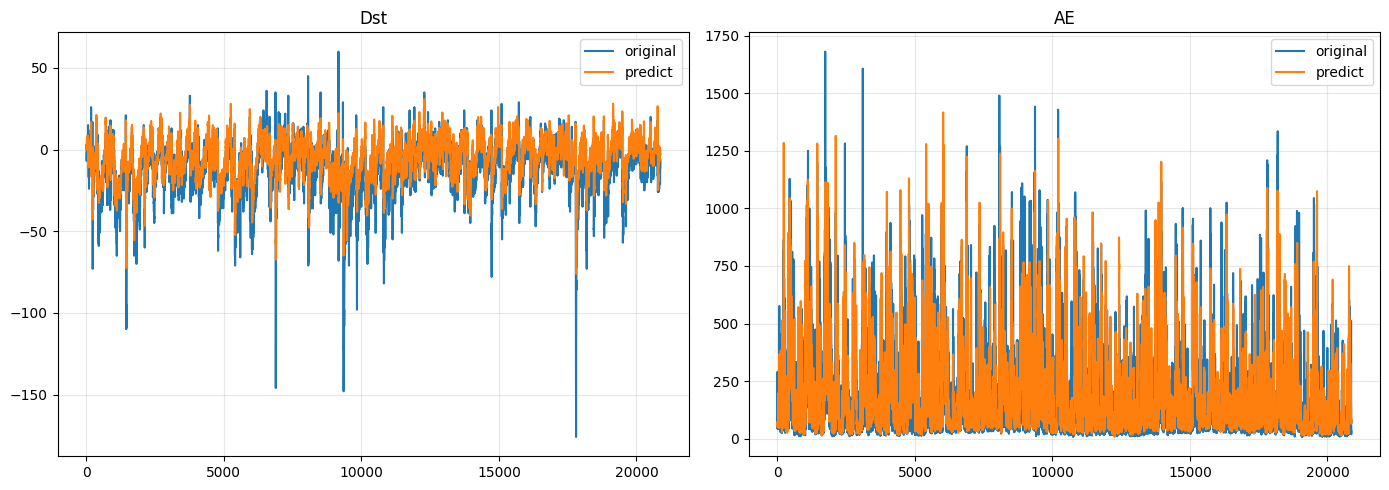

In [ ]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Dst")
axes[0].plot(dst_labels, label="original")
axes[0].plot(np.array(dst_preds), label="predict")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("AE")
axes[1].plot(ae_labels, label="original")
axes[1].plot(ae_preds, label="predict")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def visualize_model(model, loader, y_scaler):
  dst_labels = []
  ae_labels = []
  dst_preds = []
  ae_preds = []

  with torch.no_grad():
      model.eval()
      for x, y in loader:
          x, y = x.to(device), y.to(device)
          dst_pred, ae_pred, _ = model(x)
          preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
          labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
          preds = y_scaler.inverse_transform(preds)
          preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
          labels = y_scaler.inverse_transform(labels)
          labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
          dst_preds.extend(preds[:, 0])
          ae_preds.extend(preds[:, 1])
          dst_labels.extend(labels[:, 0])
          ae_labels.extend(labels[:, 1])

  _, axes = plt.subplots(1, 2, figsize=(14, 5))
  axes[0].set_title("Dst")
  axes[0].plot(dst_labels, label="original")
  axes[0].plot(np.array(dst_preds), label="predict")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].set_title("AE")
  axes[1].plot(ae_labels, label="original")
  axes[1].plot(ae_preds, label="predict")
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

In [17]:
def make_dataset(
    path,
    x_scaler,
    y_scaler,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
):
  dataset = pd.read_csv(path)
  dataset = dataset.drop(columns=["Unnamed: 0"])
  dataset['datetime'] = pd.to_datetime(
      dataset['Year'].astype(str) + '-' +
      dataset['Decimal Day'].astype(str) +
      ' ' +
      dataset['Hour'].astype(str),
      format='%Y-%j %H'
  )
  dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
  cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
  dataset = dataset[cols]

  fill_values = {
      "Bz_GSM": 999.9,
      "By_GSM": 999.9,
      "Bx_GSE": 999.9,
      "Kp": 99,
      "f10.7": 999.9,
      "AL": 99999,
      "AU": 99999,
      "T_proton": 9999999.,
      "Np_density": 999.9,
      "V_plasma": 9999.,
      "V_Long_GSE": 999.9,
      "V_Lat_GSE": 999.9,
      "Dst": 99999,
      "AE": 9999,
  }
  for col in dataset.drop(columns=["datetime"]).columns:
      dataset[col] = dataset[col].replace(fill_values[col], np.nan)

  clean_dataset = dataset.copy()
  features = [i for i in clean_dataset.columns if i != "datetime"]
  clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")

  dataset_to_preprocess = clean_dataset.copy()

  lmbda = 0
  ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

  dataset_to_preprocess["AE"] = ae_log_data

  X_test, y_test = dataset_to_preprocess.drop(columns=["datetime", "Dst", "AE"]), dataset_to_preprocess[["Dst", "AE"]]

  X_test_scaled = x_scaler.transform(X_test)

  y_test_scaled = y_scaler.transform(y_test)
  test_dataset = GeomagneticDataset(
      X=X_test_scaled,
      y=y_test_scaled,
      X_window_size=X_window_size,
      y_window_size=y_window_size,
      stride=stride,
  )
  val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
  return val_loader

In [18]:
loader_by_2019 = make_dataset(
    path="/content/test_2019.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)
loader_by_2025 = make_dataset(
    path="/content/test_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)

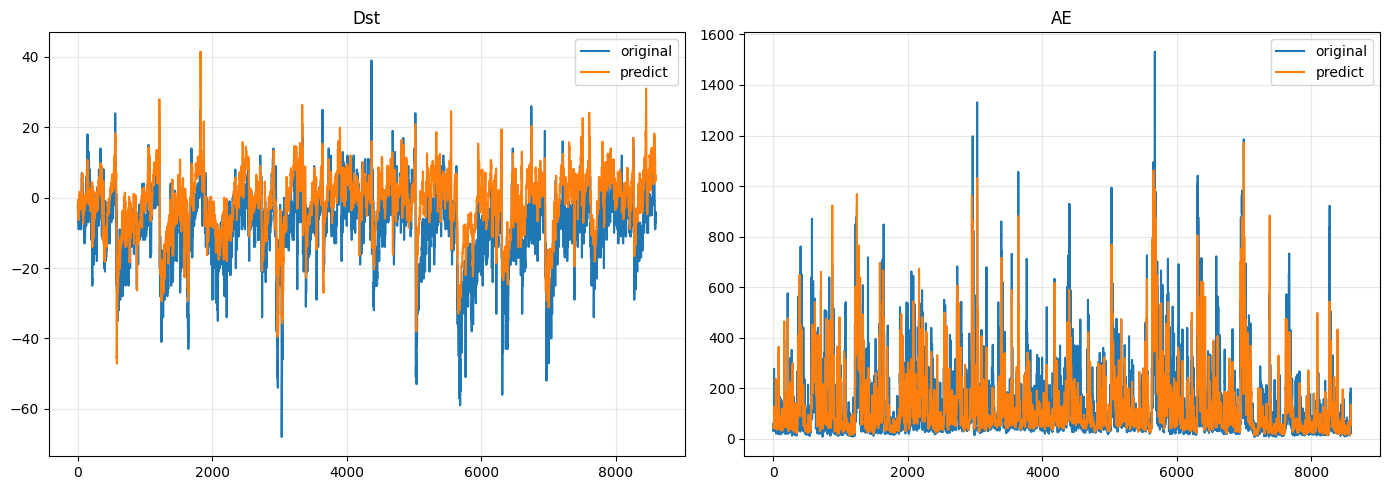

In [ ]:
baseline_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)
baseline_model.to(device)
baseline_model.load_state_dict(torch.load("/content/old/best_model_epoch_22.pt", weights_only=False)["model_state_dict"])

visualize_model(
    baseline_model,
    loader_by_2019,
    y_scaler,
)

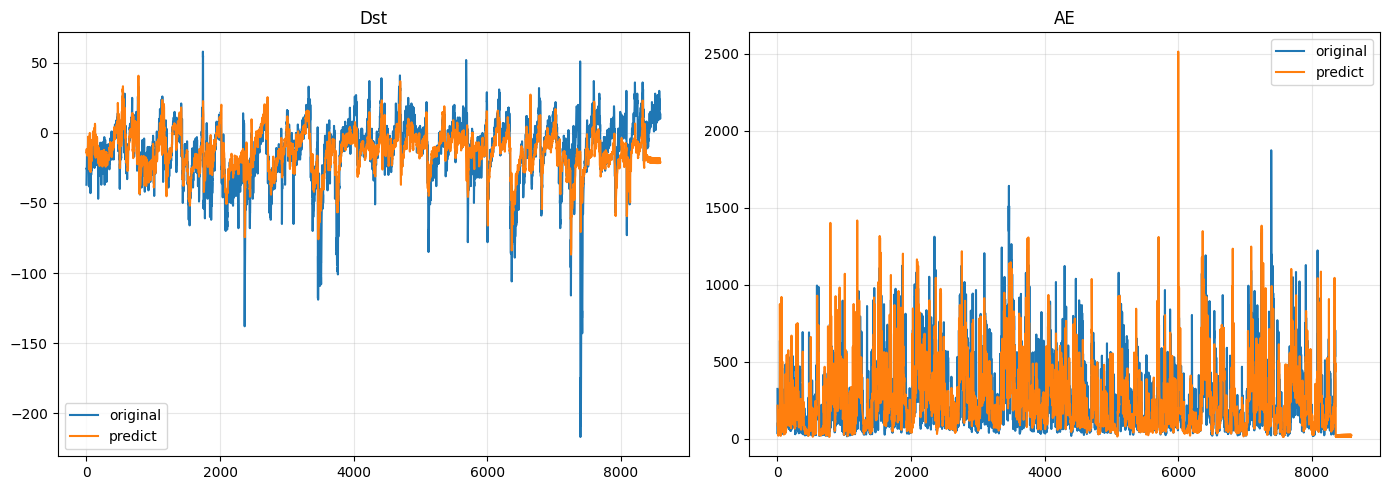

In [ ]:
visualize_model(
    baseline_model,
    loader_by_2025,
    y_scaler,
)

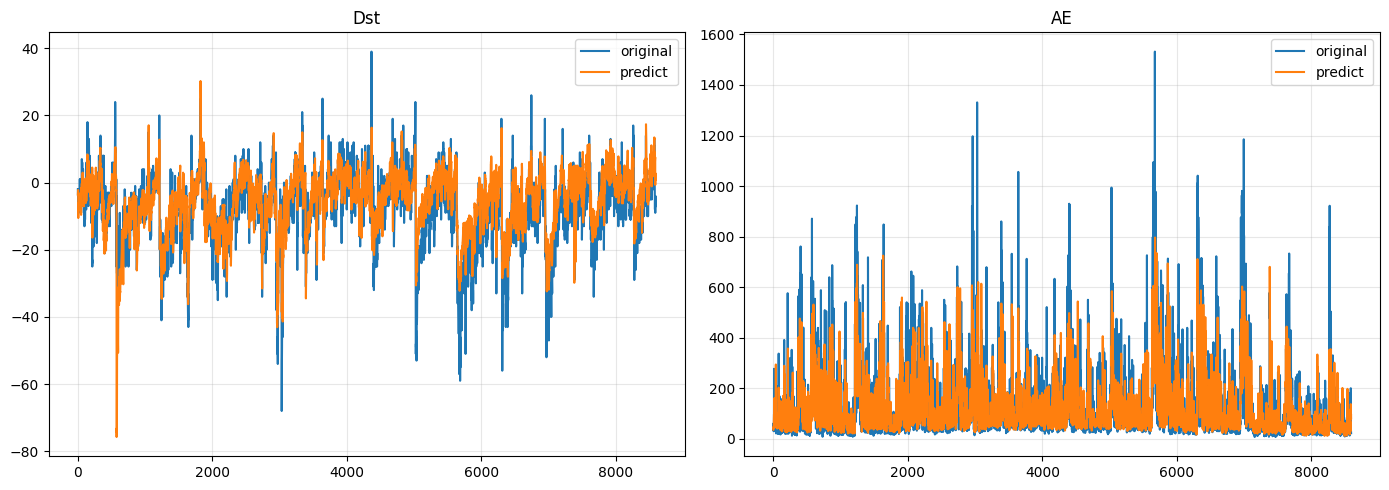

In [ ]:
baseline_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)
baseline_model.to(device)
baseline_model.load_state_dict(torch.load("/content/old/last.pt", weights_only=False))
visualize_model(
    baseline_model,
    loader_by_2019,
    y_scaler,
)

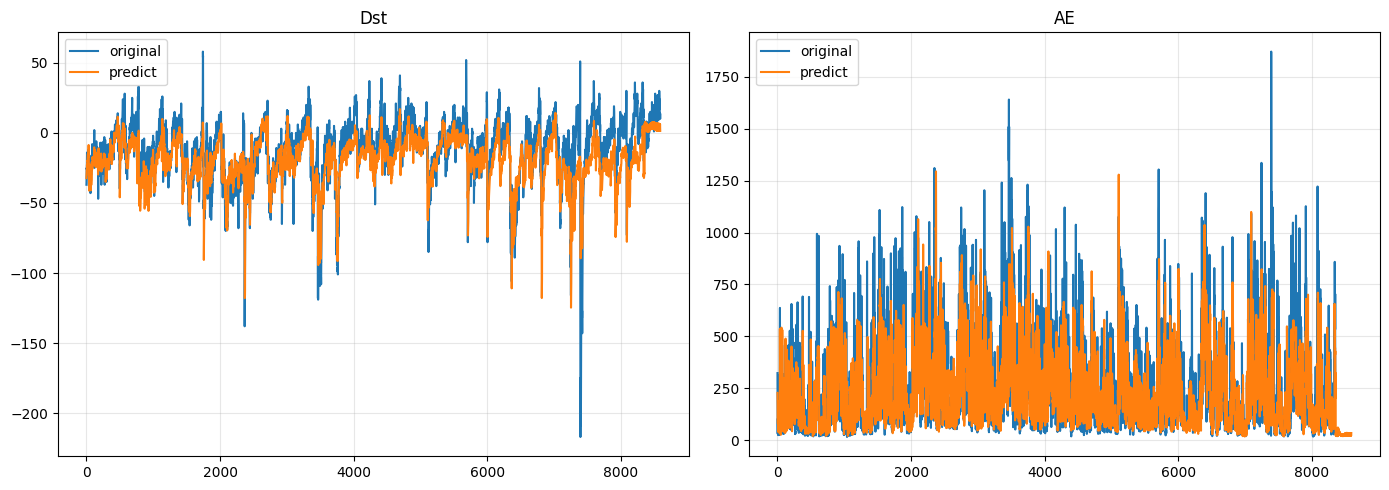

In [ ]:
visualize_model(
    baseline_model,
    loader_by_2025,
    y_scaler,
)

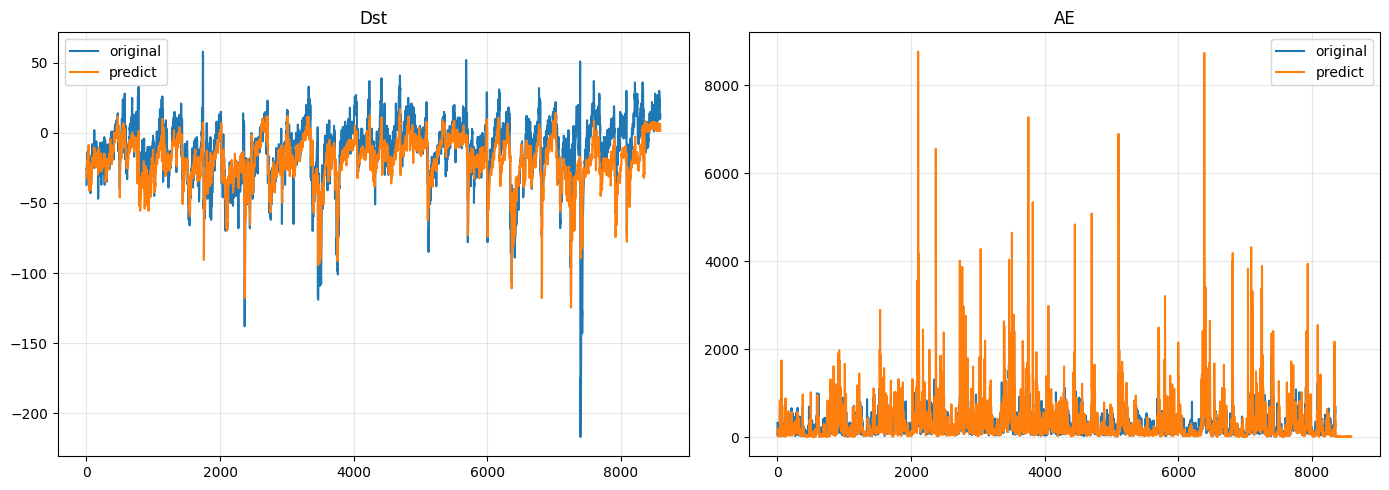

In [ ]:
nice_ae_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)
nice_ae_model.to(device)
nice_ae_model.load_state_dict(torch.load("/content/old/best_model_epoch_22.pt", weights_only=False)["model_state_dict"])
# ae
nice_dst_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)
nice_dst_model.to(device)
nice_dst_model.load_state_dict(torch.load("/content/old/last.pt", weights_only=False))
nice_dst_model.ae_head = nice_ae_model.ae_head
# nice_ae_model.dst_head = nice_dst_model.dst_head
visualize_model(
    nice_dst_model,
    loader_by_2025,
    y_scaler,
)

In [40]:
class GeomagneticNetV5(nn.Module):
    def __init__(
        self,
        lstm_input_size,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        ae_attention_heads,
        forecasts_len
    ):
        super().__init__()

        self.dst_attention = nn.MultiheadAttention(
            lstm_input_size,
            dst_attention_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.dst_attention_norm = nn.LayerNorm(lstm_input_size)
        self.ae_attention = nn.MultiheadAttention(
            lstm_input_size, ae_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_attention_norm = nn.LayerNorm(lstm_input_size)

        self.dst_lstm = nn.LSTM(
            lstm_input_size, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_lstm = nn.LSTM(
            lstm_input_size, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )

        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size * 2

        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LayerNorm(heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LayerNorm(heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        dst_attn_out, dst_attn_w = self.dst_attention(x, x, x)
        dst_x = self.dst_attention_norm(x + dst_attn_out)
        dst_out, _ = self.dst_lstm(dst_x)
        dst_features = self.dropout(dst_out[:, -1, :])
        dst = self.dst_head(dst_features)

        ae_attn_out, ae_attn_w = self.ae_attention(x, x, x)
        ae_x = self.ae_attention_norm(x + ae_attn_out)
        ae_out, _ = self.ae_lstm(ae_x)
        ae_features = self.dropout(ae_out[:, -1, :])
        ae = self.ae_head(ae_features)

        return dst, ae, (dst_attn_w, ae_attn_w)

Кол-во весов: 3983644


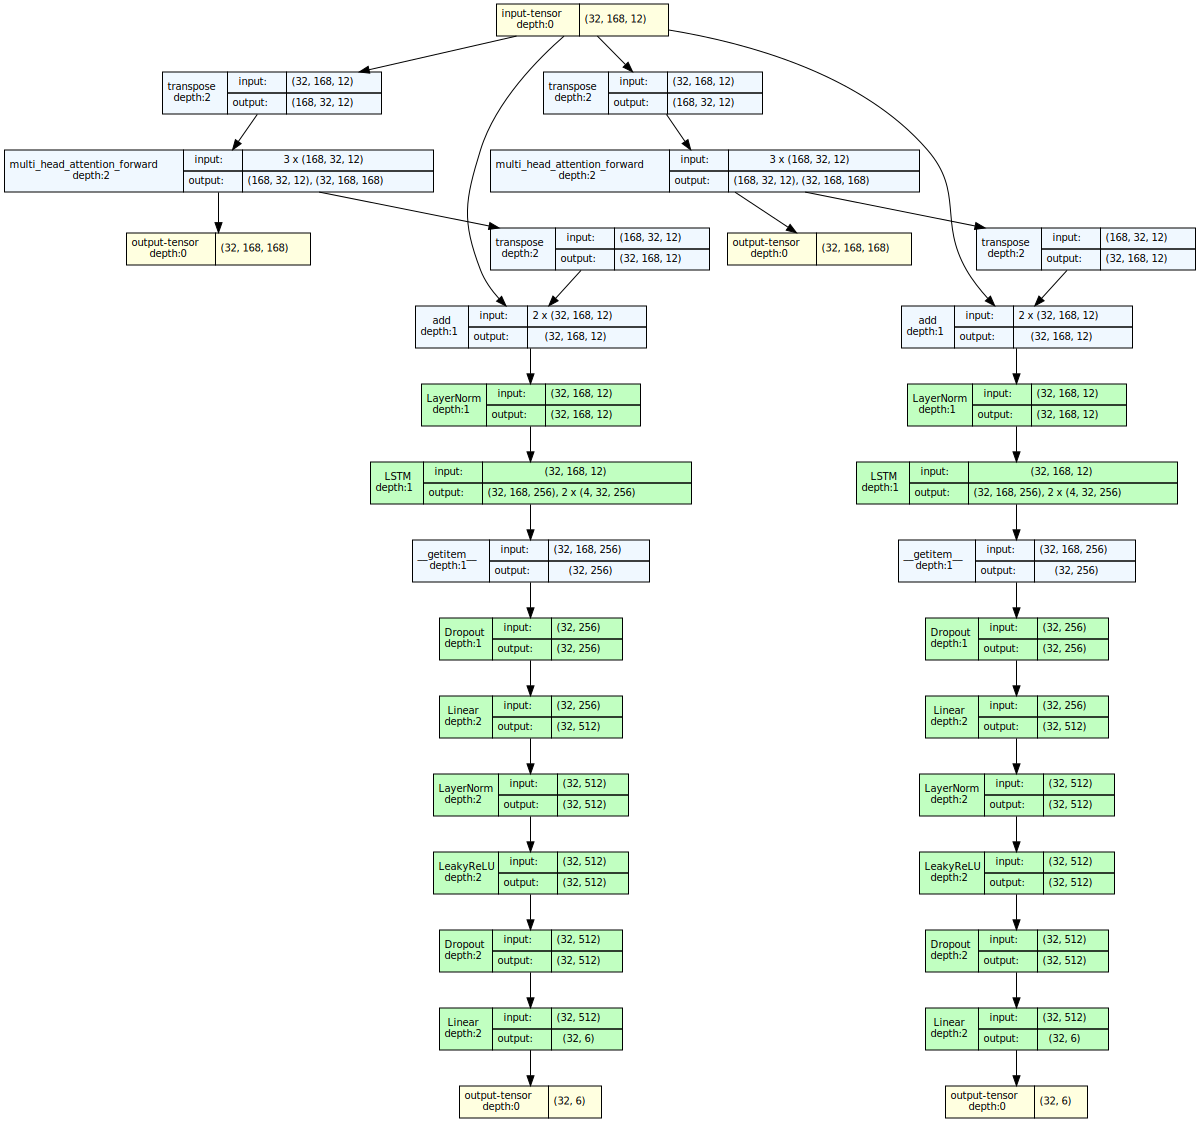

In [42]:
initial_lr = 1e-4
EPOCHS = 150

patience_counter = 0
patience_delta = 1e-4
patience = 30

best_val_loss = float('inf')
best_epoch = 0

lr_scheduler_factor = 0.7      # Умножаем lr на 0.5 при плато
lr_scheduler_patience = 10     # Ждем 10 эпох без улучшения
lr_scheduler_threshold = 1e-4  # Минимальное улучшение для сброса счетчика
lr_scheduler_cooldown = 5      # После снижения lr ждем 5 эпох
lr_scheduler_min_lr = 1e-6     # Минимальный lr

net = GeomagneticNetV5(
    lstm_input_size=12,
    lstm_hidden_size=256,
    lstm_num_layers=4,
    lstm_dropout=0.2,
    dst_attention_heads=4,
    ae_attention_heads=12,
    forecasts_len=y_window_size,
)
print(f"Кол-во весов: {sum([i.numel() for i in net.parameters()])}")
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(net.parameters(), lr=initial_lr, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_scheduler_factor,
    patience=lr_scheduler_patience,
    threshold=lr_scheduler_threshold,
    cooldown=lr_scheduler_cooldown,
    min_lr=lr_scheduler_min_lr,
)
graph = draw_graph(net, input_size=[batch_size, X_window_size, 12])
graph.visual_graph

In [ ]:
def train_geomagnetic_model(
    model,
    loss_fn,
    optimizer,
    lr_scheduler,
    # data
    epochs,
    train_loader,
    val_loader,
    y_scaler,
    lmbda,
    # early stoping
    patience,
    patience_delta,
    dst_loss_sigma=1.0,
    ae_loss_sigma=1.0,
    device="cuda"
):
  patience_counter = 0
  best_val_loss = float('inf')
  best_epoch = 0
  history_train = {
    "lr": [],
    "dst_loss": [],
    "ae_loss": [],
    "summary_loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
  }
  history_val = {
      "loss": [],
      "ae": {"RMSE": [], "MAPE": [], "MAE": []},
      "dst": {"RMSE": [], "MAPE": [], "MAE": []}
  }

  model.to(device)

  for e in range(epochs):
      # ========== TRAIN ==========
      model.train()
      train_progress = tqdm(train_loader)
      running_history = {
          "dst_loss": [],
          "ae_loss": [],
          "summary_loss": [],
          "ae": {"RMSE": [], "MAPE": [], "MAE": []},
          "dst": {"RMSE": [], "MAPE": [], "MAE": []}
      }

      for x, y in train_progress:
          x, y = x.to(device), y.to(device)
          optimizer.zero_grad()

          dst_y, ae_y = y[:, :, 0], y[:, :, 1]
          dst_y_pred, ae_y_pred, _ = model(x)

          dst_loss = loss_fn(dst_y_pred, dst_y)
          ae_loss = loss_fn(ae_y_pred, ae_y)
          loss = dst_loss * dst_loss_sigma + ae_loss_sigma * ae_loss

          loss.backward()
          optimizer.step()

          # Метрики для логирования
          with torch.no_grad():
              pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                  ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
              label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                    ae_y.detach().cpu().numpy().flatten()], axis=1)
              pred_data = y_scaler.inverse_transform(pred_data)
              pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
              label_data = y_scaler.inverse_transform(label_data)
              label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

              dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
              ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
              dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
              ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
              dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
              ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

              running_history["dst"]["RMSE"].append(dst_rmse)
              running_history["ae"]["RMSE"].append(ae_rmse)
              running_history["dst"]["MAPE"].append(dst_mape)
              running_history["ae"]["MAPE"].append(ae_mape)
              running_history["dst"]["MAE"].append(dst_mae)
              running_history["ae"]["MAE"].append(ae_mae)
              running_history["dst_loss"].append(dst_loss.item())
              running_history["ae_loss"].append(ae_loss.item())
              running_history["summary_loss"].append(loss.item())

          train_progress.set_description(
              f"Epoch [{e+1:>3}/{epochs}] [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {loss.item():.4f} AE Loss {ae_loss.item():.4f} Dst Loss {dst_loss.item():.4f}"
          )
      history_train["lr"].append(lr_scheduler.get_last_lr())
      history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
      history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
      history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
      history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
      history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
      history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
      history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
      history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
      history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))

      # ========== VALIDATION ==========
      with torch.no_grad():
          model.eval()
          val_progress = tqdm(val_loader)
          running_val = {
              "loss": [],
              "ae": {"RMSE": [], "MAPE": [], "MAE": []},
              "dst": {"RMSE": [], "MAPE": [], "MAE": []}
          }

          for x, y in val_progress:
              x, y = x.to(device), y.to(device)
              dst_y, ae_y = y[:, :, 0], y[:, :, 1]
              dst_y_pred, ae_y_pred, _ = model(x)

              # Validation loss
              dst_loss = loss_fn(dst_y_pred, dst_y)
              ae_loss = loss_fn(ae_y_pred, ae_y)
              val_loss = dst_loss + ae_loss
              running_val["loss"].append(val_loss.item())

              # Метрики для логирования
              pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                  ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
              label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                    ae_y.detach().cpu().numpy().flatten()], axis=1)
              pred_data = y_scaler.inverse_transform(pred_data)
              pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
              label_data = y_scaler.inverse_transform(label_data)
              label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

              dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
              ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
              dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
              ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
              dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
              ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

              running_val["dst"]["RMSE"].append(dst_rmse)
              running_val["ae"]["RMSE"].append(ae_rmse)
              running_val["dst"]["MAPE"].append(dst_mape)
              running_val["ae"]["MAPE"].append(ae_mape)
              running_val["dst"]["MAE"].append(dst_mae)
              running_val["ae"]["MAE"].append(ae_mae)

              val_progress.set_description(
                  f"Epoch [{e+1:>3}/{epochs}] [VAL  ] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {val_loss.item():.4f}"
              )
          current_val_loss = np.mean(running_val["loss"])
          history_val["loss"].append(current_val_loss)
          history_val["dst"]["RMSE"].append(np.mean(running_val["dst"]["RMSE"]))
          history_val["ae"]["RMSE"].append(np.mean(running_val["ae"]["RMSE"]))
          history_val["dst"]["MAPE"].append(np.mean(running_val["dst"]["MAPE"]))
          history_val["ae"]["MAPE"].append(np.mean(running_val["ae"]["MAPE"]))
          history_val["dst"]["MAE"].append(np.mean(running_val["dst"]["MAE"]))
          history_val["ae"]["MAE"].append(np.mean(running_val["ae"]["MAE"]))
      lr_scheduler.step(metrics=current_val_loss)
      if current_val_loss < best_val_loss - patience_delta:
          best_val_loss = current_val_loss
          best_epoch = e + 1
          torch.save(model.state_dict(), f"./best_model_epoch_{best_epoch}.pt")
          patience_counter = 0
          print(f"New best model! Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")
          print(f"Val DST RMSE: {history_val['dst']['RMSE'][-1]:.3f}, AE RMSE: {history_val['ae']['RMSE'][-1]:.3f}")
      else:
          patience_counter += 1
      if patience_counter >= patience:
          print(f"Early stopping triggered at epoch {e+1}")
          print(f"Best model was at epoch {best_epoch} with val loss: {best_val_loss:.6f}")
          # checkpoint = torch.load(f"./best_model_epoch_{best_epoch}.pt")
          torch.save(model.state_dict(), f"./last.pt")
          break
    return model, history_train, history_val

In [ ]:
initial_lr = 1e-4
EPOCHS = 150
patience_delta = 1e-4
patience = 30
best_val_loss = float('inf')
best_epoch = 0
lr_scheduler_factor = 0.7      # Умножаем lr на 0.5 при плато
lr_scheduler_patience = 10     # Ждем 10 эпох без улучшения
lr_scheduler_threshold = 1e-4  # Минимальное улучшение для сброса счетчика
lr_scheduler_cooldown = 5      # После снижения lr ждем 5 эпох
lr_scheduler_min_lr = 1e-6     # Минимальный lr

net = GeomagneticNetV5(
    lstm_input_size=12,
    lstm_hidden_size=256,
    lstm_num_layers=4,
    lstm_dropout=0.2,
    dst_attention_heads=4,
    ae_attention_heads=12,
    forecasts_len=y_window_size,
)
print(f"Кол-во весов: {sum([i.numel() for i in net.parameters()])}")
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(net.parameters(), lr=initial_lr, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_scheduler_factor,
    patience=lr_scheduler_patience,
    threshold=lr_scheduler_threshold,
    cooldown=lr_scheduler_cooldown,
    min_lr=lr_scheduler_min_lr,
)

train_geomagnetic_model(
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    # data
    epochs=EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    y_scaler=y_scaler,
    lmbda=lmbda,
    # early stoping
    patience=patience,
    patience_delta=patience_delta,
    dst_loss_sigma=1.0,
    ae_loss_sigma=1.5,
    device="cuda"
)

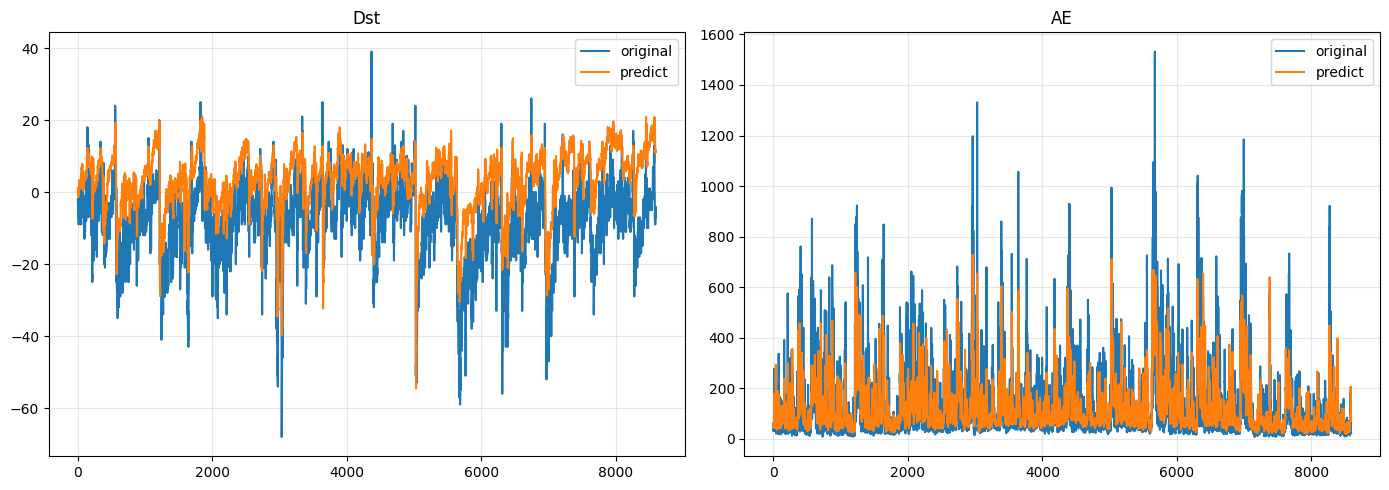

In [52]:
visualize_model(
    net,
    loader_by_2019,
    y_scaler,
)

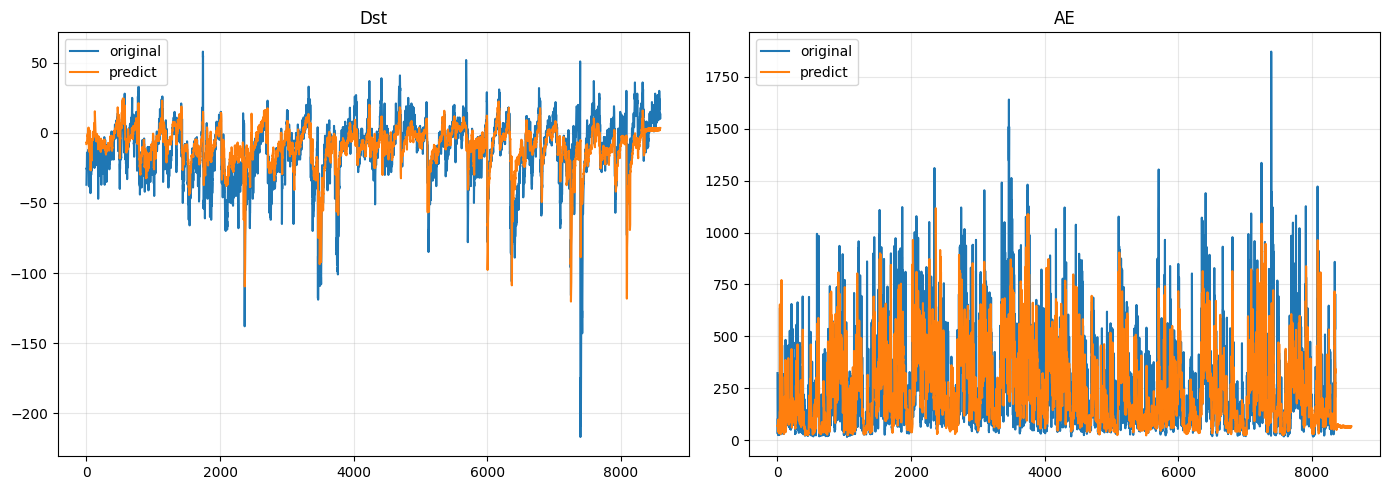

In [53]:
visualize_model(
    net,
    loader_by_2025,
    y_scaler,
)